In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy.stats
from linearmodels import PanelOLS


West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
#West_EU = ["Germany", "France", "Belgium", "Netherlands", "Austria"]
East_EU = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

ALL_COUNTRIES = West_EU + East_EU + South_EU + Nord_EU
#ALL_COUNTRIES = West_EU

#TARGET = ["buildings_rest_TWh"]
TARGET = ["ln_building_rest"]
#FEATURES = ["population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC", "cdd_DegreesC"]
#FEATURES = ["ln_pop", "ln_gdp_pc", "ln_hdd", "ln_cdd"]
FEATURES = ["ln_pop", "ln_gdp_pc", "ln_hdd"]

In [2]:
# importing the transformed data prepared before
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv")
panel = panel[["year", "country", "population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC", "cdd_DegreesC", 'ln_pop', 'ln_gdp_pc', 'ln_hdd', 'ln_cdd', "demand_oth_TWh"]]
panel

,year,country,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,demand_oth_TWh
0,1990,Austria,7.644818,43177.35409,3.299014,3647.948556,25.646842,2.156960,10.673095,8.202194,3.282671,22.017
1,1990,Belgium,9.947782,41647.81322,3.299014,2276.951920,46.296132,2.393137,10.637028,7.731032,3.856429,26.212
2,1990,Bulgaria,8.767308,13688.68504,3.299014,2416.963240,129.481837,2.279041,9.524398,7.790681,4.871234,15.415
3,1990,Croatia,4.772556,17519.10144,3.299014,1947.345518,106.441446,1.753115,9.771104,7.574736,4.676946,6.950
4,1990,Czechia,10.362102,30937.81727,3.299014,3008.033596,32.228258,2.430283,10.339767,8.009374,3.503401,18.088
...,...,...,...,...,...,...,...,...,...,...,...,...
1217,2060,Romania,16.333523,72256.62000,1.007720,2543.820865,360.308119,2.852642,11.187993,7.841816,5.889731,NaN
1218,2060,Slovakia,4.850265,69326.40000,0.888031,2855.311013,182.376955,1.766487,11.146595,7.957286,5.211544,NaN
1219,2060,Slovenia,2.047613,81846.32000,1.617258,2240.830881,195.764920,1.114359,11.312611,7.715048,5.282010,NaN
1220,2060,Spain,53.468132,75910.47000,1.517263,1176.424436,363.398075,3.997616,11.237323,7.071085,5.898247,NaN


In [3]:
# creating the hist and proj data frames
hist = panel[(panel.year >= 2010) & (panel.year <= 2024)]

proj = panel[(panel.year >= 2025)]
proj = proj.drop(["demand_oth_TWh"], axis=1)
#proj
hist

,year,country,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,demand_oth_TWh
520,2010,Austria,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.644606
521,2010,Belgium,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700
522,2010,Bulgaria,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000
523,2010,Croatia,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.117000
524,2010,Czechia,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000
...,...,...,...,...,...,...,...,...,...,...,...,...
905,2024,Romania,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,24.743164
906,2024,Slovakia,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,11.539000
907,2024,Slovenia,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,7.236503
908,2024,Spain,48.619695,48336.54351,3.337132,1305.524034,243.637986,3.904388,10.785964,7.175125,5.499780,157.070536


# defining plotting function

In [4]:
def plot_heat_demand(
    hist,
    proj,
    hist_actual_col="buildings_rest_TWh",
    hist_pred_col="ML_predictions",
    proj_pred_col="buildings_rest_TWh_ML",
    countries_list=None,
    train_test_split_year=2020,          # draws a dashed red vertical line
    title="Electricity Demand Buildings (excl. Heat Pumps & Data Centers): Actuals, Model Fit & Projection",
):
    if countries_list is None:
        countries_list = sorted(hist.index.get_level_values("country").unique().tolist())

    n     = len(countries_list)
    ncols = 5
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(21, nrows * 3),
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    for i, country in enumerate(countries_list):
        ax = axes_flat[i]

        # ── Actual historical values (solid blue) ───────────────────────────
        try:
            actual = hist[hist_actual_col].xs(country, level="country")
            ax.plot(actual.index, actual.values,
                    "-", color="steelblue", lw=1.5, label="Actual")
        except KeyError:
            pass

        # ── Historical model predictions (dotted orange) ────────────────────
        if hist_pred_col in hist.columns:
            try:
                pred = hist[hist_pred_col].xs(country, level="country")
                ax.plot(pred.index, pred.values,
                        ":", color="darkorange", lw=1.8, label=f"Model ({hist_pred_col})")
            except KeyError:
                pass

        # ── Future projection (dashed green) ────────────────────────────────
        if proj_pred_col is not None and proj_pred_col in proj.columns:
            try:
                fut = proj[proj_pred_col].xs(country, level="country")
                ax.plot(fut.index, fut.values,
                        "--", color="seagreen", lw=1.5, label=f"Projection ({proj_pred_col})")
            except KeyError:
                pass

        # ── Train / test split line (dashed red) ────────────────────────────
        if train_test_split_year is not None:
            ax.axvline(x=train_test_split_year, color="red", lw=1.0, ls="--", alpha=0.3,
                       label=f"Train/Test split ({train_test_split_year})" if i == 0 else "_nolegend_")

        ax.set_title(country, fontsize=9, fontweight="bold")
        ax.set_ylabel("Electricity Demand (TWh)", fontsize=7)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylim(bottom=0)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend above the grid
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.04)

    return None

# preparing historical data of data centers and heat pumps to be subtracted from historical demand_oth_TWh

In [5]:
# reading historical data of data centers
dc_hist = pd.read_excel("Results/data_centers_demand.xlsx", sheet_name="Historical_2010_2024", index_col="country")

dc_hist = dc_hist.loc[:, [y for y in range(2010, 2025)]]
dc_hist = dc_hist.head(26)

dc_hist = dc_hist.sort_index()
#dc_hist

In [6]:
# reading the historical data of heat pumps (Heat consumption in TJ)
hp_hist = pd.read_csv("Data - raw/prepared_data/hist_hp_heat_demand.csv", index_col=0)
hp_hist = hp_hist[["country", "year", "Energy_TJ"]]

# COP specific for each country - tunable via scenario_config.py (same values used in heat_pump_ols.ipynb)
from scenario_config import COP_MAP
hp_hist["COP"] = hp_hist["country"].map(COP_MAP)

# calculating the electricity demand from heat demand
hp_hist["Demand_HP_TWh"] = (
    hp_hist["Energy_TJ"]
    * (1 / 3600)
    / (hp_hist["COP"])
)

# only keeping the important columns
hp_hist = hp_hist[["country", "year", "Demand_HP_TWh"]]
#hp_hist

hp_hist_wide = hp_hist.pivot(index="country", columns="year", values="Demand_HP_TWh").sort_index()
hp_hist_wide = hp_hist_wide.ffill(axis=1)
#hp_hist_wide

In [7]:
dc_hp_hist = hp_hist_wide + dc_hist
dc_hp_hist = dc_hp_hist.reset_index()
dc_hp_hist = dc_hp_hist.melt(
    id_vars="country",
    var_name="year",
    value_name="dc_hp_demand_TWh"
)

# add a new column in hist df as Building_rest_TWh, which is the whole 'Others' sector (Buildings: Demand_oth_TWh) minus heat pump and data centers.
hist = hist.set_index(["country", "year"])
dc_hp_hist = dc_hp_hist.set_index(["country", "year"])
hist = hist.join(dc_hp_hist)
hist.dc_hp_demand_TWh = hist.dc_hp_demand_TWh.fillna(0)

hist["buildings_rest_TWh"] = hist["demand_oth_TWh"] - hist["dc_hp_demand_TWh"]

hist = hist.drop(["demand_oth_TWh", "dc_hp_demand_TWh"], axis=1).reset_index()
#hist = hist.reset_index()

hist#[hist.country=="Germany"]

,country,year,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,buildings_rest_TWh
0,Austria,2010,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.397191
1,Belgium,2010,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700
2,Bulgaria,2010,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000
3,Croatia,2010,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.076315
4,Czechia,2010,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000
...,...,...,...,...,...,...,...,...,...,...,...,...
385,Romania,2024,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,23.140999
386,Slovakia,2024,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,10.698743
387,Slovenia,2024,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,6.545954
388,Spain,2024,48.619695,48336.54351,3.337132,1305.524034,243.637986,3.904388,10.785964,7.175125,5.499780,151.085659


In [8]:
hist = hist.set_index(["country", "year"])
proj = proj.set_index(["country", "year"])
hist["ln_building_rest"] = np.log1p(hist["buildings_rest_TWh"])

# BSO Daten

In [9]:
bso = pd.read_excel("Heat Pump/heat_pumps.xlsx", sheet_name="heat_spec_distribution")
bso = bso[:27] # keeping only relevant data
bso = bso[bso.Country.isin(ALL_COUNTRIES)]
bso = bso.set_index("Country")

bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [10]:
# Importing the Data for Norway in the format Above from Excel Caculations from SSB.no website!
norway_floor = pd.read_excel("Heat Pump/Norway_building_floor_data.xlsx", sheet_name="Norway_floor_data_2020", index_col=0)


bso = pd.concat([bso, norway_floor])
bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,480479871,0.226669,0.265689,0.153497,0.123125,0.141204,0.069105,0.02071
Belgium,693785280,0.411845,0.217941,0.121747,0.084841,0.064261,0.062943,0.036422
Bulgaria,321201659,0.20838,0.226748,0.145953,0.137376,0.107167,0.111183,0.063192
Croatia,182977135,0.129597,0.171136,0.183956,0.140586,0.128498,0.157216,0.089011
Czechia,387472106,0.178462,0.208683,0.203641,0.127887,0.087488,0.1155,0.078338
Denmark,341768565,0.206363,0.182657,0.200548,0.101004,0.100508,0.106585,0.102335
Estonia,27472583,0.330614,0.211147,0.085553,0.076144,0.117936,0.115091,0.063515
Finland,406877934,0.146812,0.234661,0.147952,0.186731,0.123418,0.133904,0.026521
France,3087013302,0.182696,0.141576,0.155983,0.149489,0.098669,0.147054,0.124533


In [11]:
# floor area and thermal index now come from floor_area_panel.ipynb instead of being
# calculated here - it reconstructs 2010-2024 from Eurostat building permits and
# projects 2025-2060 with demand-driven construction, demolition and renovation rates.

FLOOR_PANEL_PATH        = "Data - raw/prepared_data/floor_panel_2010_2060.csv"
from scenario_config import FLOOR_BASELINE_SCENARIO   # scenario used for the single-pathway `proj`
FLOOR_COLS = ["ln_total_floor", "ln_thermal_index", "total_floor_m2", "thermal_index"]

floor_all = pd.read_csv(FLOOR_PANEL_PATH)
floor_all = floor_all[floor_all.country.isin(ALL_COUNTRIES)]

# history 2010–2024: observation-based, identical across scenarios
floor_hist_panel = (floor_all[floor_all.scenario == "HIST"]
                    .set_index(["country", "year"])[FLOOR_COLS])

# projection 2025–2060: one row per country × year × scenario
floor_proj_panel = floor_all[floor_all.scenario != "HIST"][
    ["country", "year", "scenario"] + FLOOR_COLS]

# baseline pathway for the non-scenario `proj` further down
floor_proj_baseline = (floor_proj_panel[floor_proj_panel.scenario == FLOOR_BASELINE_SCENARIO]
                       .drop(columns="scenario")
                       .set_index(["country", "year"]))

floor_panel = pd.concat([floor_hist_panel, floor_proj_baseline])

print(f"floor panel: {len(floor_hist_panel)} historical + "
      f"{len(floor_proj_panel)} projected rows "
      f"({floor_proj_panel.scenario.nunique()} scenarios)")
floor_panel.head()

floor panel: 390 historical + 1248 projected rows (4 scenarios)


ln_total_floor  ln_thermal_index  total_floor_m2  thermal_index
country year                                                                 
Austria 2010       19.984013          5.233116    4.774705e+08     186.375709
        2011       19.984307          5.231496    4.776108e+08     186.072483
        2012       19.984831          5.229711    4.778613e+08     185.738758
        2013       19.985131          5.228090    4.780048e+08     185.436328
        2014       19.985605          5.226345    4.782314e+08     185.111245

In [12]:
# Adding total_floor_m2 and "thermal_index" to hist and proj to be used in the model
# total_floor_m2 shows how much area needs to be heated
# thermal_index shows how old are the buildings in a country
BUILDING_FEATURES = ["ln_total_floor", "ln_thermal_index"]
FEATURES = FEATURES + BUILDING_FEATURES

hist = hist.join(floor_panel)
proj = proj.join(floor_panel)

assert hist[BUILDING_FEATURES].notna().all().all(), "missing floor data in hist"
assert proj[BUILDING_FEATURES].notna().all().all(), "missing floor data in proj"
hist.head()

,,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,buildings_rest_TWh,ln_building_rest,ln_total_floor,ln_thermal_index,total_floor_m2,thermal_index
country,year,,,,,,,,,,,,,,,
Austria,2010,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.397191,3.446718,19.984013,5.233116,4.774705e+08,186.375709
Belgium,2010,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700,3.800481,20.339709,5.331460,6.814334e+08,205.739497
Bulgaria,2010,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000,2.990016,19.536187,5.203411,3.051113e+08,180.891658
Croatia,2010,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.076315,2.570803,18.942530,5.110326,1.685141e+08,164.724316
Czechia,2010,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000,3.459498,19.706891,5.190070,3.619044e+08,178.481061


# PanelOLS Model

In [13]:
def predict_logaritmic(model, df, X, LN=True):
    # it gets the model (PanelOLS) and a dataFrame containing features to predict the target variable in a new column "panel_predictions"
    
    # saving the entity effects per country
    entity_effects = model.estimated_effects.groupby('country')["estimated_effects"].mean()

    # predicting the ln(Target)
    df["panel_predictions"] = model.predict(X)["predictions"]

    # adding the entity effect to ln(Target)
    df["panel_predictions"] = (
    df["panel_predictions"]
        + df.index.get_level_values("country").map(entity_effects)
    )

    # # calculate the exponential of it, because the model is on "ln"
    if LN:
        df["panel_predictions"] = np.expm1(df["panel_predictions"])

    return df

In [14]:
hist

,,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,cdd_DegreesC,ln_pop,ln_gdp_pc,ln_hdd,ln_cdd,buildings_rest_TWh,ln_building_rest,ln_total_floor,ln_thermal_index,total_floor_m2,thermal_index
country,year,,,,,,,,,,,,,,,
Austria,2010,8.351643,59595.26217,1.710849,3913.126161,26.592030,2.235552,10.995348,8.272347,3.317527,30.397191,3.446718,19.984013,5.233116,4.774705e+08,186.375709
Belgium,2010,10.839905,56252.04416,2.589410,2814.201579,38.285869,2.471476,10.937615,7.942789,3.670865,43.722700,3.800481,20.339709,5.331460,6.814334e+08,205.739497
Bulgaria,2010,7.421766,21707.49126,1.605189,2287.352789,150.780000,2.130820,9.985459,7.735588,5.022432,18.886000,2.990016,19.536187,5.203411,3.051113e+08,180.891658
Croatia,2010,4.302847,28698.16467,-1.269480,2098.359098,102.941067,1.668244,10.264623,7.649387,4.643824,12.076315,2.570803,18.942530,5.110326,1.685141e+08,164.724316
Czechia,2010,10.462088,38893.27089,2.685070,3488.360840,33.041979,2.439045,10.568602,8.157474,3.527594,30.801000,3.459498,19.706891,5.190070,3.619044e+08,178.481061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Romania,2024,19.067576,42788.02854,0.866539,2665.710459,232.404997,2.999105,10.664037,7.888601,5.452775,23.140999,3.183912,19.891886,5.057751,4.354481e+08,156.236458
Slovakia,2024,5.424687,40058.05158,1.927404,2964.396618,65.308558,1.860148,10.598110,7.994766,4.194319,10.698743,2.459481,18.936972,5.145331,1.675801e+08,170.628207
Slovenia,2024,2.123949,48474.69700,1.633377,2444.807005,89.379514,1.139098,10.788818,7.802130,4.504018,6.545954,2.021012,18.002353,5.138661,6.581465e+07,169.487308


In [15]:
X = hist[FEATURES]
Y = hist[TARGET]

#X = sm.add_constant(X)

m_panelOLS = PanelOLS(Y, X,
                      entity_effects=True,
                      ).fit(
                        #cov_type="clustered",
                        #cluster_entity=True,
                      )
m_panelOLS

Dep. Variable:,ln_building_rest,R-squared:,0.2517
Estimator:,PanelOLS,R-squared (Between):,-437.31
No. Observations:,390,R-squared (Within):,0.2517
Date:,"Mon, Aug 17 2026",R-squared (Overall):,-437.24
Time:,11:37:41,Log-likelihood,704.60
Cov. Estimator:,Unadjusted,,
,,F-statistic:,24.155
Entities:,26,P-value,0.0000
Avg Obs:,15.000,Distribution:,"F(5,359)"
Min Obs:,15.000,,
Max Obs:,15.000,F-statistic (robust):,24.155


In [16]:
# predictions for historical data
hist = predict_logaritmic(m_panelOLS, hist, X, LN=True)

# Raw model projection 2025–2060
X_proj = proj[FEATURES]
#X_proj = sm.add_constant(X_proj)
proj = predict_logaritmic(m_panelOLS, proj, X_proj, LN=True)

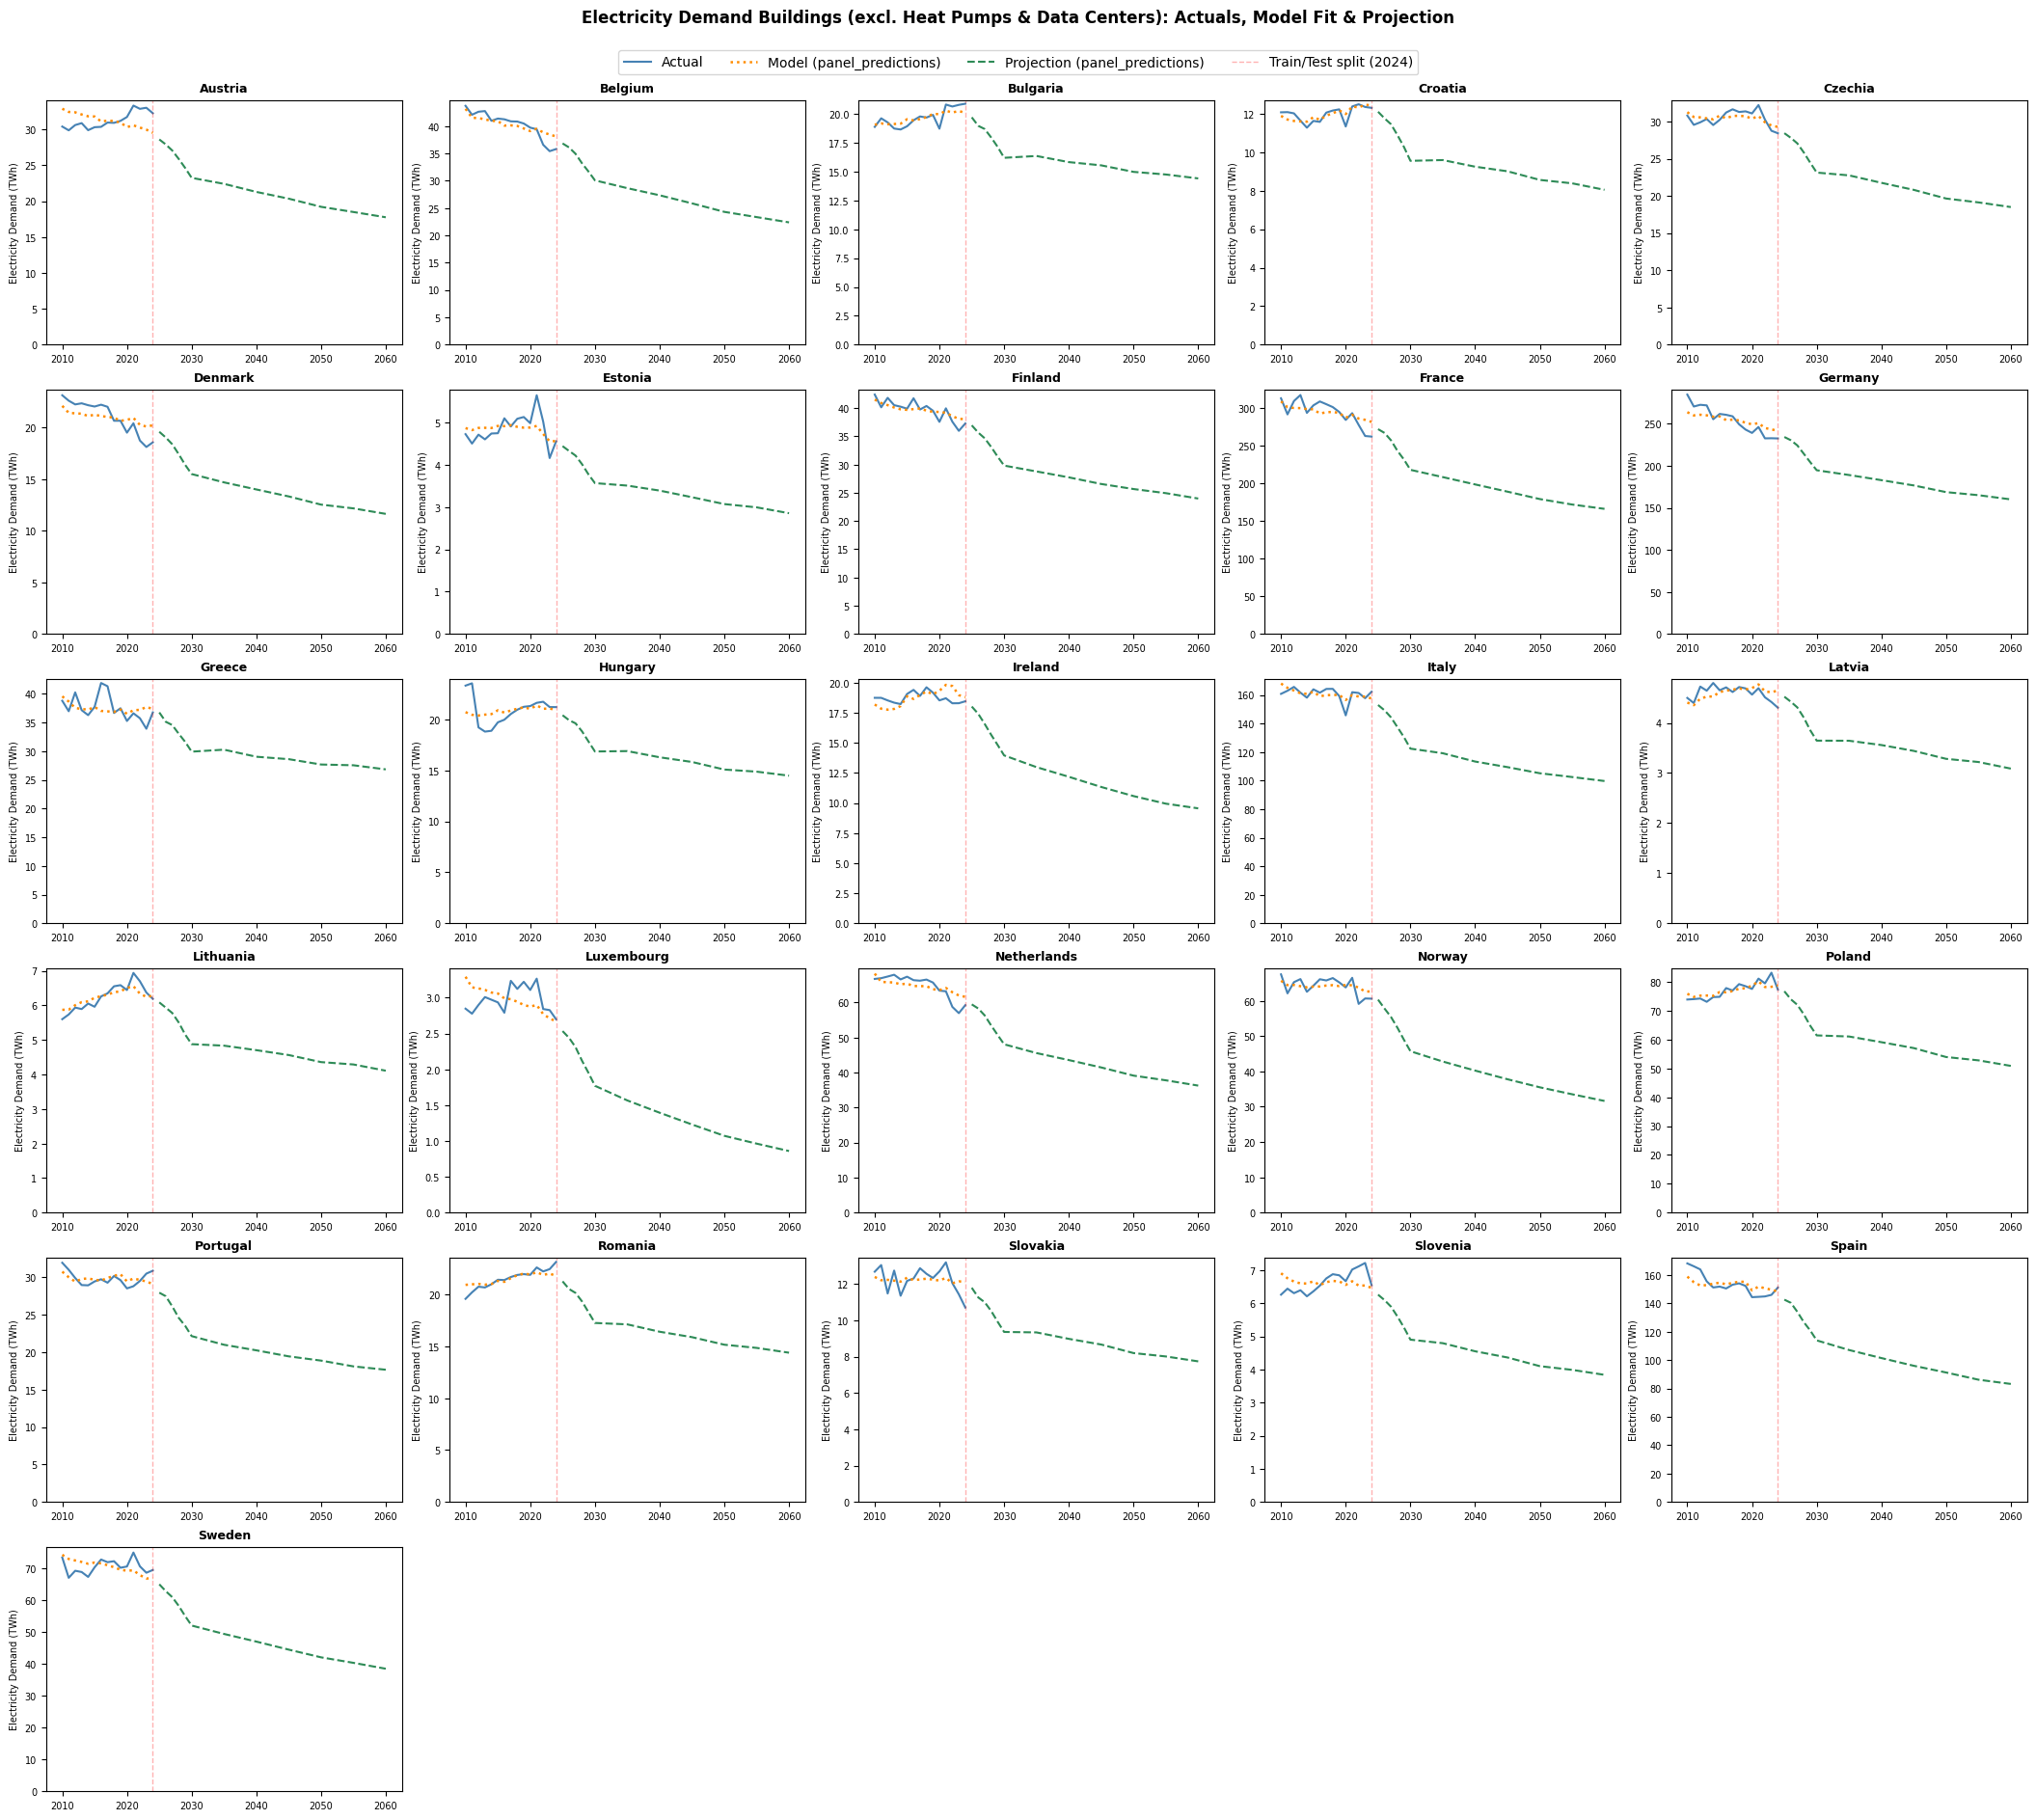

In [17]:
# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="buildings_rest_TWh",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="panel_predictions",          # change to "Total_Heat_TJ_ML" when ready
    train_test_split_year=hist.index.get_level_values('year').max()
)

## Scenario-Based HDD/CDD Projection (SSP1/SSP2/SSP3/SSP5)

Everything above trains the model once and produces one projection (`proj`) from the single
RCP4.5 HDD/CDD pathway in `panel_transformed.csv`.

Set `USE_HDD_CDD_SCENARIOS = True` to build four buildings-rest electricity-demand projections
instead, one per climate scenario, using the scenario-specific HDD/CDD from
`Data - raw/chdd_data/chdd_calculation_scenarios.ipynb`. Scenario labels match the
heat-pump-adoption scenarios used in `heat_pump_ols.ipynb`'s `SCENARIOS` dict:

| Climate scenario | Scenario label |
|-------------------|----------------|
| SSP1 (SP126)       | KKO            |
| SSP2 (SP245)       | KVE            |
| SSP5 (SP585)       | VWE            |
| SSP3 (SP370)       | VNI            |

`m_panelOLS` (already trained above) is reused as-is - only HDD/CDD changes per scenario,
population/GDP/floor area stay the same across scenarios. If `USE_HDD_CDD_SCENARIOS = False`,
this section is a no-op.

In [18]:
# four climate-scenario HDD/CDD paths (SSP1/SSP2/SSP3/SSP5) instead of the single
# RCP4.5 pathway above. Tunable via scenario_config.py.
from scenario_config import USE_HDD_CDD_SCENARIOS, CLIMATE_SCENARIO_MAP

if USE_HDD_CDD_SCENARIOS:
    hdd_cdd_scenarios = pd.read_csv("Data - raw/chdd_data/output_csv/hdd_cdd_scenarios_2025_2060.csv")
    hdd_cdd_scenarios = hdd_cdd_scenarios[["scenario", "country", "year", "hdd_annual", "cdd_annual"]]
    hdd_cdd_scenarios = hdd_cdd_scenarios.rename(columns={"hdd_annual": "hdd_DegreesC", "cdd_annual": "cdd_DegreesC"})
    hdd_cdd_scenarios = hdd_cdd_scenarios[hdd_cdd_scenarios["country"].isin(ALL_COUNTRIES)]

    # scenario-independent projection features (population, gdp, floor area, ...)
    # NOTE: the floor columns are dropped here and re-merged per scenario below
    proj_base = proj.drop(columns=["hdd_DegreesC", "cdd_DegreesC", "ln_hdd", "ln_cdd"] + FLOOR_COLS,
                          errors="ignore").reset_index()

    proj_scenarios = hdd_cdd_scenarios.merge(proj_base, on=["country", "year"], how="left")
    proj_scenarios = proj_scenarios.merge(floor_proj_panel,
                                          on=["country", "year", "scenario"], how="left")
    proj_scenarios["ln_hdd"] = np.log1p(proj_scenarios["hdd_DegreesC"])
    proj_scenarios["ln_cdd"] = np.log1p(proj_scenarios["cdd_DegreesC"])
    proj_scenarios = proj_scenarios.set_index(["country", "year"])

    assert proj_scenarios[FEATURES].notna().all().all(), "missing features in proj_scenarios"

    # predict buildings_rest_TWh (ln model) for every scenario using the model trained above
    # (this must be recomputed here: proj_base carried over the single-pathway `panel_predictions`
    # column from `proj`, which is stale and identical across scenarios until overwritten)
    X_proj_scenarios = proj_scenarios[FEATURES]
    proj_scenarios = predict_logaritmic(m_panelOLS, proj_scenarios, X_proj_scenarios, LN=True)

proj_scenarios[proj_scenarios.index.get_level_values("country") == "Germany"] if USE_HDD_CDD_SCENARIOS else None


scenario  hdd_DegreesC  cdd_DegreesC  population_Mio  \
country year                                                        
Germany 2025      KKO   2439.863882     52.544875       83.577140   
        2026      KKO   2431.036785     47.962508       83.499996   
        2027      KKO   2407.282421     38.703778       83.377681   
        2028      KKO   2535.384527     56.406822       83.250170   
        2029      KKO   2362.028508     48.035075       83.122146   
        2030      KKO   2759.779750     13.650640       82.990067   
        2035      KKO   2481.341807     26.230867       82.331992   
        2040      KKO   2484.236468     77.942948       81.721963   
        2045      KKO   2707.724990     85.253497       81.050460   
        2050      KKO   2354.191672     32.261403       80.277587   
        2055      KKO   1986.220307     57.557817       79.415128   
        2060      KKO   2187.777673     44.114780       78.505228   
        2025      KVE   2130.400980    118.341572       83.577140   
        2026      KVE   2303.489402     90.215913       83.499996   
        2027      KVE   2411.036293     76.350035       83.377681   
        2028      KVE   2445.572258     96.359043       83.250170   
        2029      KVE   2185.413758     97.066778       83.122146   
        2030      KVE   2553.100190     40.727137       82.990067   
        2035      KVE   2364.869045     29.003630       82.331992   
        2040      KVE   2430.402038    138.849018       81.721963   
        2045      KVE   2397.532440     35.419405       81.050460   
        2050      KVE   2243.263507     66.148197       80.277587   
        2055      KVE   2092.056704     66.633030       79.415128   
        2060      KVE   2356.840931     70.449510       78.505228   
        2025      VNI   2724.870011     79.326290       83.577140   
        2026      VNI   2215.402640     60.768990       83.499996   
        2027      VNI   2426.186334     47.113473       83.377681   
        2028      VNI   2646.151619     11.529065       83.250170   
        2029      VNI   2495.052386     36.187460       83.122146   
        2030      VNI   2226.554240    112.215210       82.990067   
        2035      VNI   2366.087068     25.031815       82.331992   
        2040      VNI   2466.245874     31.854077       81.721963   
        2045      VNI   2164.930315     57.507577       81.050460   
        2050      VNI   2118.240383    165.768998       80.277587   
        2055      VNI   2025.362355     87.280378       79.415128   
        2060      VNI   2392.414483     29.513670       78.505228   
        2025      VWE   2578.967876     16.469417       83.577140   
        2026      VWE   2303.951916     50.752090       83.499996   
        2027      VWE   2185.814800     48.222702       83.377681   
        2028      VWE   2550.685523     36.029990       83.250170   
        2029      VWE   2407.700115     77.468388       83.122146   
        2030      VWE   2238.873610     37.202728       82.990067   
        2035      VWE   2323.076088     63.964928       82.331992   
        2040      VWE   2274.746214     74.211765       81.721963   
        2045      VWE   2522.179680    103.447648       81.050460   
        2050      VWE   2379.710918     59.353740       80.277587   
        2055      VWE   2509.420441     37.010165       79.415128   
        2060      VWE   2237.673537    100.062405       78.505228   

              gdp_per_capita_USD  gdp_growth_rate_Percent    ln_pop  \
country year                                                          
Germany 2025         62128.11189                 0.402901  4.437664   
        2026         62924.90581                 1.189015  4.436751   
        2027         63547.13000                 0.840903  4.435303   
        2028         64127.54000                 0.759025  4.433791   
        2029         64683.70000                 0.712156  4.432270   
        2030         65264.19000                 0.737105  4.4306

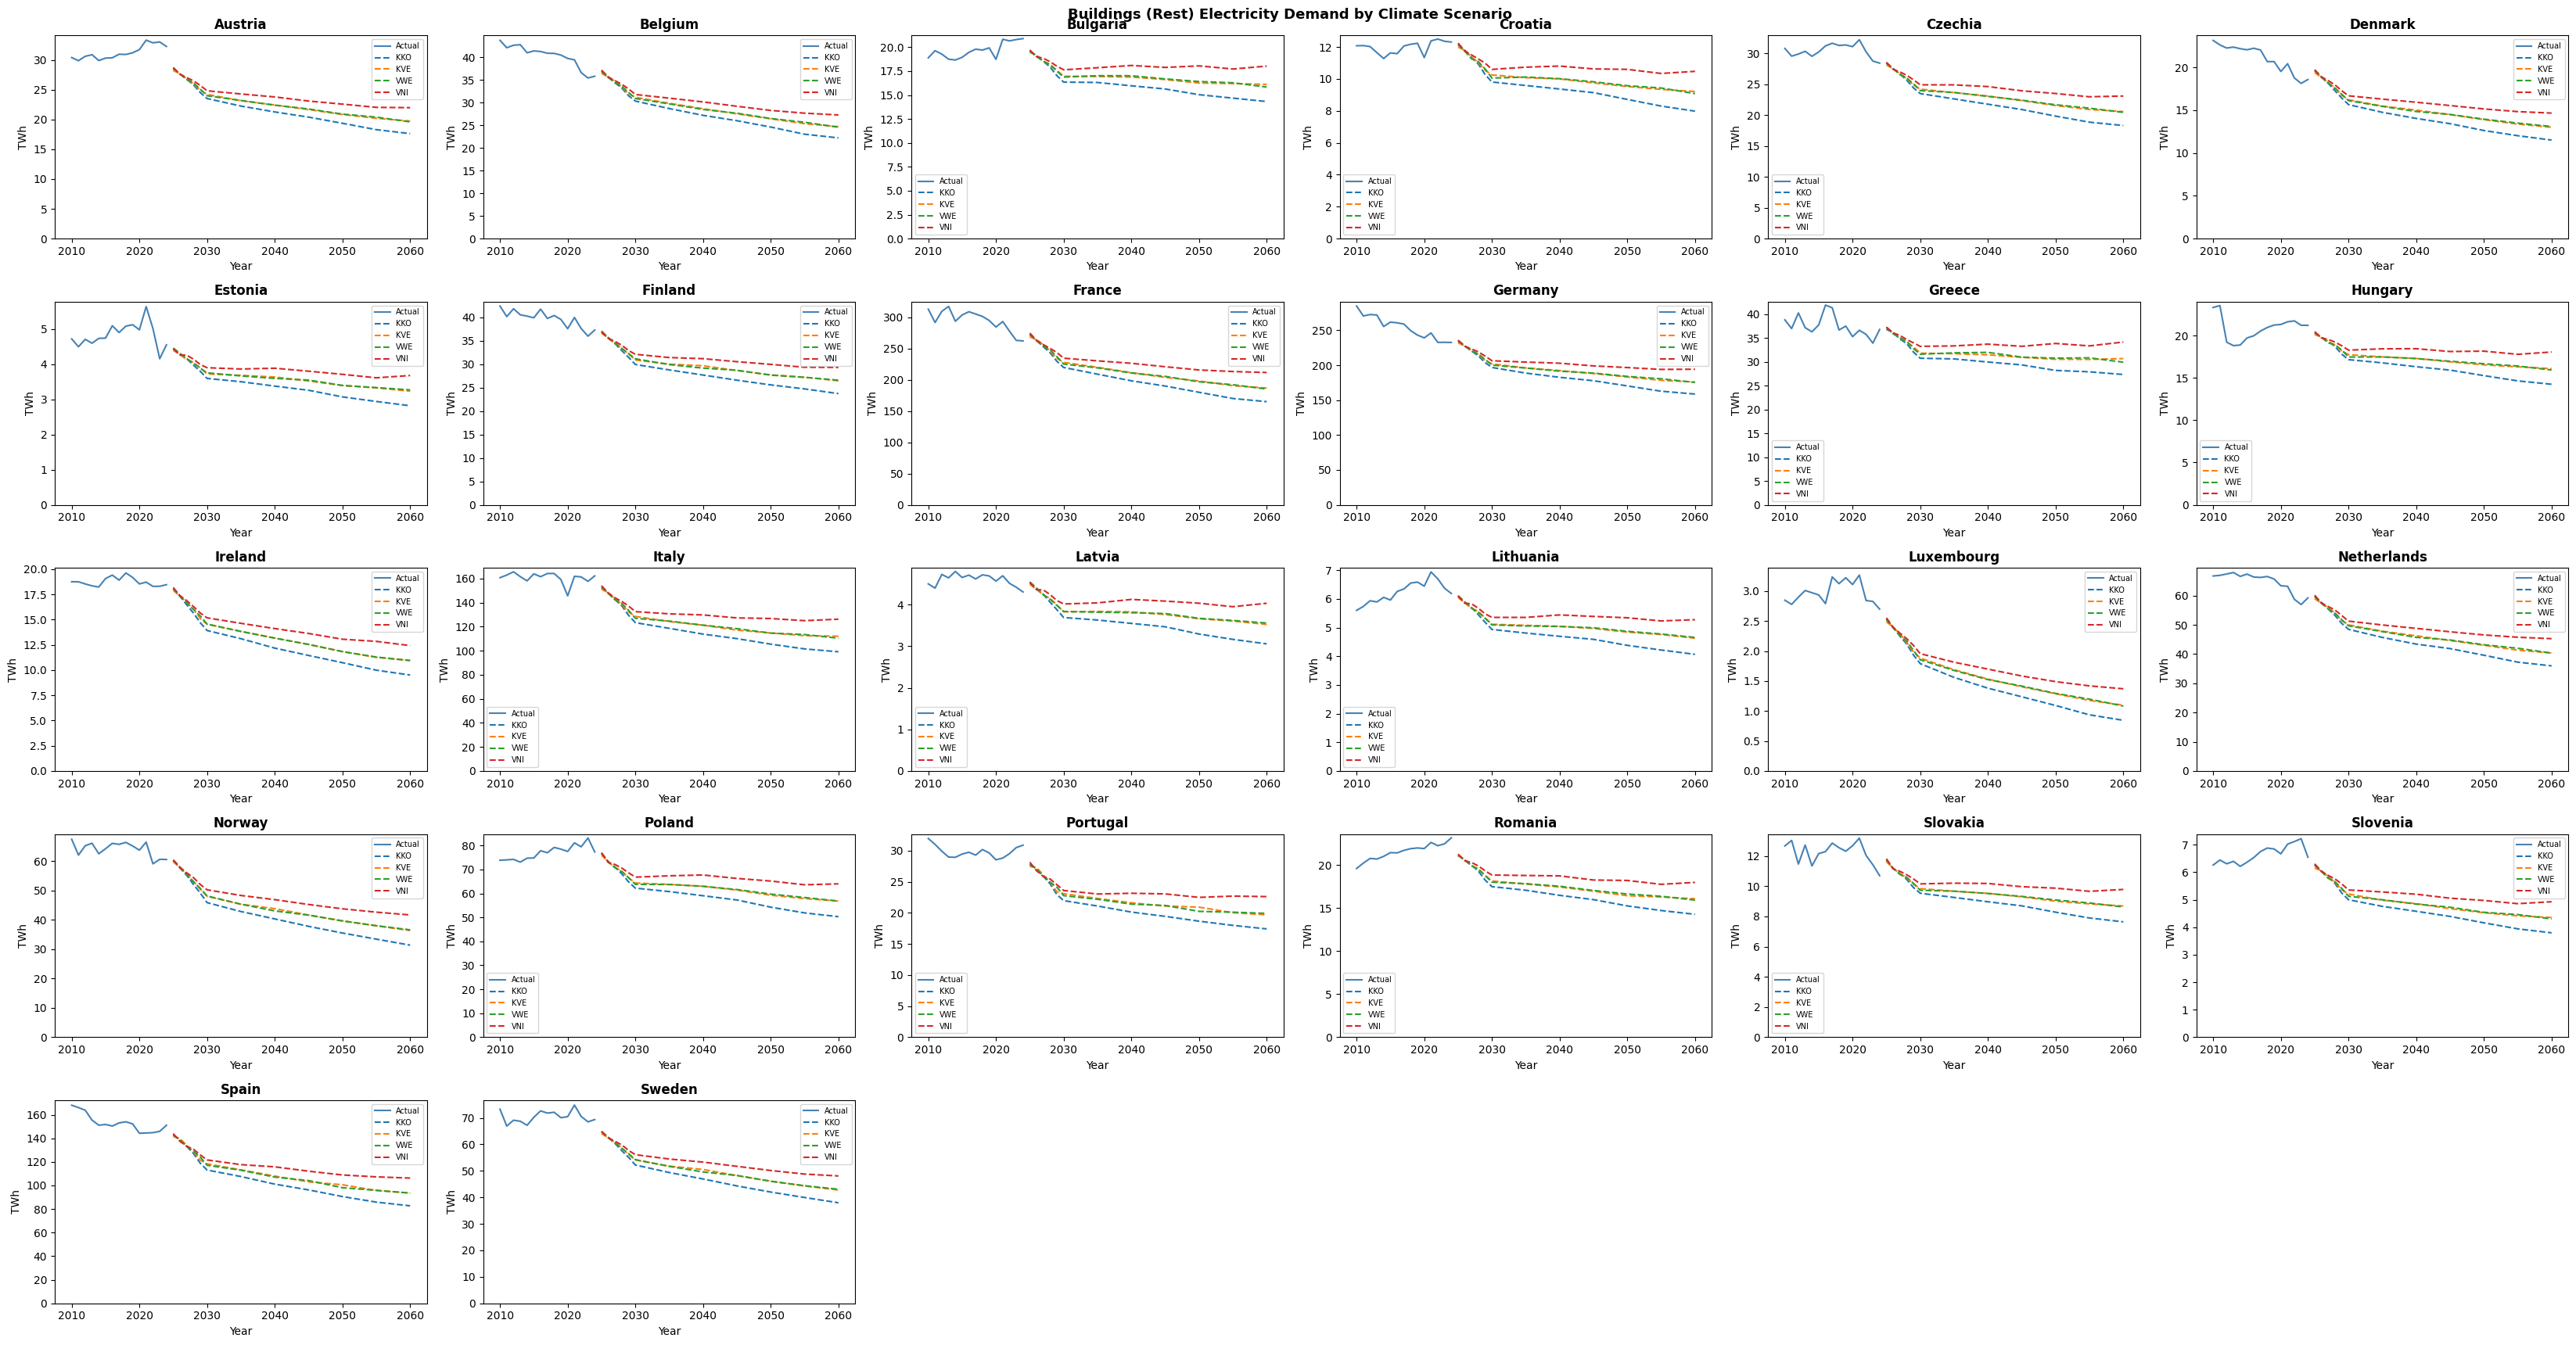

In [19]:
# Plot buildings-rest electricity demand per country, one colored line per climate scenario
# (mirrors the scenario-colored grid plot in heat_pump_ols.ipynb)
if USE_HDD_CDD_SCENARIOS:
    import math

    CHECK_COUNTRIES = sorted(ALL_COUNTRIES)
    n_cols = 6
    n_rows = math.ceil(len(CHECK_COUNTRIES) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5.5, n_rows * 3.5))
    axes = axes.flatten()

    hist_reset = hist.reset_index()
    proj_scenarios_reset = proj_scenarios.reset_index()

    for ax, country in zip(axes, CHECK_COUNTRIES):
        actual = hist_reset[hist_reset["country"] == country]
        ax.plot(actual["year"], actual["buildings_rest_TWh"],
                "-", color="steelblue", lw=1.5, label="Actual")

        for scenario in CLIMATE_SCENARIO_MAP:
            d = proj_scenarios_reset[
                (proj_scenarios_reset["country"] == country) &
                (proj_scenarios_reset["scenario"] == scenario)
            ]
            ax.plot(d["year"], d["panel_predictions"], "--", label=scenario)

        ax.set_title(country, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("TWh")
        ax.legend(fontsize=7)
        ax.set_ylim(bottom=0)

    for ax in axes[len(CHECK_COUNTRIES):]:
        ax.set_visible(False)

    plt.suptitle("Buildings (Rest) Electricity Demand by Climate Scenario",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


In [20]:
proj[proj.index.get_level_values("country").isin(["Germany"])]

population_Mio  gdp_per_capita_USD  gdp_growth_rate_Percent  \
country year                                                                
Germany 2025       83.577140         62128.11189                 0.402901   
        2026       83.499996         62924.90581                 1.189015   
        2027       83.377681         63547.13000                 0.840903   
        2028       83.250170         64127.54000                 0.759025   
        2029       83.122146         64683.70000                 0.712156   
        2030       82.990067         65264.19000                 0.737105   
        2035       82.331992         69040.80000                 1.163004   
        2040       81.721963         74568.03000                 1.459517   
        2045       81.050460         80540.13000                 1.305019   
        2050       80.277587         86404.64000                 1.178026   
        2055       79.415128         92169.80000                 1.056781   
        2060       78.505228         98654.39000                 1.223914   

              hdd_DegreesC  cdd_DegreesC    ln_pop  ln_gdp_pc    ln_hdd  \
country year                                                              
Germany 2025   2461.934004     17.403123  4.437664  11.036970  7.809109   
        2026   2912.511039     23.298619  4.436751  11.049713  7.977114   
        2027   3141.458422     46.628866  4.435303  11.059553  8.052761   
        2028   2745.421863     78.190539  4.433791  11.068645  7.918054   
        2029   2464.020376     77.267424  4.432270  11.077280  7.809955   
        2030   2373.458405    117.095232  4.430699  11.086214  7.772525   
        2035   2556.867923     30.099023  4.422833  11.142467  7.846929   
        2040   2551.776111     27.038250  4.415485  11.219481  7.844937   
        2045   2468.586279     57.402847  4.407334  11.296523  7.811806   
        2050   2047.838406     80.641767  4.397870  11.366808  7.625028   
        2055   2462.241292     55.920372  4.387202  11.431399  7.809233   
        2060   2497.037922     92.541102  4.375823  11.499388  7.823261   

                ln_cdd  ln_total_floor  ln_thermal_index  total_floor_m2  \
country year                                                               
Germany 2025  2.912520       22.075394          5.193596    3.865644e+09   
        2026  3.190420       22.077834          5.184269    3.875086e+09   
        2027  3.863439       22.078964          5.174963    3.879469e+09   
        2028  4.371857       22.079833          5.164817    3.882841e+09   
        2029  4.360131       22.080573          5.153698    3.885715e+09   
        2030  4.771491       22.081340          5.141449    3.888697e+09   
        2035  3.437176       22.088224          5.124220    3.915557e+09   
        2040  3.333570       22.101109          5.102102    3.966339e+09   
        2045  4.067365       22.113189          5.080465    4.014542e+09   
        2050  4.402341       22.122155          5.061109    4.050698e+09   
        2055  4.041653       22.128398          5.043718    4.076066e+09   
        2060  4.538401       22.134816          5.026526    4.102310e+09   

              thermal_index  panel_predictions  
country year                                    
Germany 2025     179.115077         234.371755  
        2026     177.442938         230.518741  
        2027     175.790054         224.390946  
        2028     174.005406         214.426054  
        2029     172.070242         204.353631  
        2030     169.963246         194.807883  
        2035     167.043100         189.120189  
        2040     163.367067         183.009130  
        2045     159.848847         176.717169  
        2050     156.765311         168.765525  
        2055     154.045414         165.132398  
        2060     151.402714         160.119677

In [21]:
proj_scenarios.to_csv("Results/building_demand_proj.csv")
proj_scenarios

scenario  hdd_DegreesC  cdd_DegreesC  population_Mio  \
country year                                                        
Austria 2025      KKO   3187.680977     75.432853        9.197213   
        2026      KKO   3293.199687     35.903955        9.219116   
        2027      KKO   3305.007484     29.453943        9.234675   
        2028      KKO   3470.538489     19.409915        9.251146   
        2029      KKO   3134.594626     31.071490        9.268632   
...               ...           ...           ...             ...   
Sweden  2040      VWE   3578.687949     12.077435       11.108521   
        2045      VWE   4205.020807      0.456678       11.293147   
        2050      VWE   3798.938739      0.211152       11.457559   
        2055      VWE   3946.736032      3.825072       11.584352   
        2060      VWE   4205.661852      1.713123       11.667100   

              gdp_per_capita_USD  gdp_growth_rate_Percent    ln_pop  \
country year                                                          
Austria 2025         62963.14442                -0.036296  2.322114   
        2026         63580.49807                 1.220983  2.324260   
        2027         64983.96000                 2.379872  2.325781   
        2028         66031.00000                 1.792463  2.327390   
        2029         66898.02000                 1.504546  2.329094   
...                          ...                      ...       ...   
Sweden  2040         81496.18000                 1.943838  2.493909   
        2045         87990.98000                 1.834170  2.509042   
        2050         94148.38000                 1.543703  2.522328   
        2055        100097.00000                 1.405289  2.532454   
        2060        106829.70000                 1.537496  2.539008   

              ln_gdp_pc  panel_predictions  ln_total_floor  ln_thermal_index  \
country year                                                                   
Austria 2025  11.050321          28.484812       19.995536          5.198034   
        2026  11.060078          27.662444       20.000489          5.186728   
        2027  11.081911          26.748590       20.007937          5.172385   
        2028  11.097895          25.805785       20.013937          5.158129   
        2029  11.110940          24.508547       20.019268          5.143305   
...                 ...                ...             ...               ...   
Sweden  2040  11.308324          49.592349       20.169515          4.867169   
        2045  11.385001          48.261776       20.206233          4.829207   
        2050  11.452638          46.077985       20.238535          4.794418   
        2055  11.513905          44.397473       20.265708          4.763220   
        2060  11.579001          43.056074       20.290004          4.734635   

              total_floor_m2  thermal_index    ln_hdd    ln_cdd  
country year                                                     
Austria 2025    4.830042e+08     179.916287  8.067363  4.336413  
        2026    4.854026e+08     177.882245  8.099919  3.608319  
        2027    4.890313e+08     175.334807  8.103497  3.416215  
        2028    4.919743e+08     172.838954  8.152353  3.016021  
        2029    4.946039e+08     170.280898  8.050574  3.467967  
...                      ...            ...       ...       ...  
Sweden  2040    5.747899e+08     128.952562  8.183031  2.570888  
        2045    5.962872e+08     124.111678  8.344272  0.376158  
        2050    6.158630e+08     119.834069  8.242740  0.191572  
        2055    6.328274e+08     116.122479  8.280898  1.573826  
        2060    6.483906e+08     112.821884  8.344425  0.998100  

[1248 rows x 15 columns]